# DataCleaning-Rev: Revised Data Cleaning Pipeline

## Critical Anomaly: Suspiciously Low Average Transaction Value (ATV)

**Issue discovered during EDA (06-EDA.ipynb):**  
The final EDA reports total revenue of **~Rp444 million** across **~14.6 million transactions**, yielding an **Average Transaction Value of approximately Rp30.36**.

**Why this is suspicious:**  
This is a Malaysian coffee shop chain (G Coffee) where menu prices range from **RM6 to RM10 per item** and customers typically buy **2–3 items per visit**. The expected ATV should be in the range of **RM12–RM30**, not ~RM30.

**But wait — the ATV is ~30, and menu items are 6–10 each.**  *Actually, ~30 for 2.5 average items ≈ 12 per item, which is plausible.*  
However, the concern is about the **unit of measurement**:
- If `final_amount` is in **sen / cents** (1/100 of RM), then the real ATV is RM0.30 — _impossibly low_
- If `final_amount` is in **RM**, then ATV = ~RM30 — _plausible but at the low end for coffee shops_
- If `final_amount` has been **pre-capped or truncated**, then the real ATV may be masked

**Recommended action for the team:**  
1. Verify the currency unit of `original_amount`, `discount_applied`, and `final_amount` against the original Kaggle data description.
2. Check if any conversion or scaling factor was applied (or should be applied).
3. If amounts are confirmed to be in **RM / Rupiah** with no scaling, the data may reflect individual *item-level* per-unit prices rather than transaction totals. Confirm whether `final_amount` = sum of item-level prices or if it has another meaning.
4. This ATV value is used in downstream financial reports (06-EDA) — validate before presenting to stakeholders.

---

## Key Improvements Over 03-DataCleaning.ipynb

| # | Fix | Description |
|---|-----|-------------|
| 1 | **Data Preservation** | `original_amount_header` is now backed up BEFORE overwriting, preserving the raw financial record |
| 2 | **Logic Reordering** | `original_amount` correction now runs BEFORE discount validation, so `calculated_discount` uses fresh, accurate values |
| 3 | **Deterministic Dedup** | Duplicate items now keep the row with the **maximum subtotal** instead of whichever row appears last after sorting |
| 4 | **Band-Aid Removed** | The discount capping logic is preserved (still needed) but it now runs against corrected original_amount, making it a genuine safeguard rather than a workaround for stale data |
| 5 | **Scale Investigation** | This markdown cell flags the suspicious Rp30 ATV for team follow-up |

---

In [5]:
from function import CleaningData
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

In [6]:
df_Trans = pd.read_parquet('transactions.parquet')
df_TransItem = pd.read_parquet('transaction_items.parquet')
df_Users = pd.read_parquet('users.parquet')
df_stores = pd.read_parquet('stores.parquet')
df_menu = pd.read_parquet('menu_items.parquet')
df_vouchers = pd.read_parquet('vouchers.parquet')
df_payment = pd.read_parquet('paymentsUnique.parquet')
gc.collect()

3020

# Katalog Data

## df Trans

In [7]:
df_Trans.describe(include='all')

,transaction_id,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at
count,14623691,1.462369e+07,1.462369e+07,617551.0,7312864.0,1.462369e+07,1.462369e+07,1.462369e+07,14623691
unique,14623691,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
top,2ae6d188-76c2-4095-b861-ab97d3cd9312,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
mean,NaN,5.500704e+00,2.999922e+00,7.913672,714031.918498,3.324469e+01,1.582853e-01,3.308640e+01,2024-06-30 12:02:59.537388544
min,NaN,1.000000e+00,1.000000e+00,1.0,1.0,6.000000e+00,0.000000e+00,1.000000e+00,2023-07-01 07:00:00
25%,NaN,3.000000e+00,2.000000e+00,4.0,206788.0,1.900000e+01,0.000000e+00,1.900000e+01,2023-12-30 13:54:59.500000
50%,NaN,6.000000e+00,3.000000e+00,8.0,562156.0,3.100000e+01,0.000000e+00,3.100000e+01,2024-06-30 12:12:01
75%,NaN,8.000000e+00,4.000000e+00,12.0,1119509.0,4.550000e+01,0.000000e+00,4.500000e+01,2024-12-30 10:58:21.500000
max,NaN,1.000000e+01,5.000000e+00,16.0,2196257.0,9.000000e+01,4.500000e+01,9.000000e+01,2025-06-30 19:59:39


## df_TransItem

In [8]:
df_TransItem.describe(include="all")

,transaction_id,item_id,quantity,unit_price,subtotal,created_at
count,29246323,2.924632e+07,2.924632e+07,2.924632e+07,2.924632e+07,29246323
unique,14623691,NaN,NaN,NaN,NaN,NaN
top,44b450c2-c6af-4e82-85b3-8e6345cdd99c,NaN,NaN,NaN,NaN,NaN
freq,3,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.499000e+00,1.999876e+00,8.311932e+00,1.662295e+01,2024-06-30 12:19:29.214134016
min,NaN,1.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,2023-07-01 07:00:00
25%,NaN,2.000000e+00,1.000000e+00,7.000000e+00,9.000000e+00,2023-12-30 14:08:08
50%,NaN,4.000000e+00,2.000000e+00,8.000000e+00,1.600000e+01,2024-06-30 12:18:32
75%,NaN,6.000000e+00,3.000000e+00,9.000000e+00,2.100000e+01,2024-12-30 10:53:19
max,NaN,8.000000e+00,3.000000e+00,1.000000e+01,3.000000e+01,2025-06-30 19:59:39


## df_Users

In [9]:
df_Users.describe(include='all')

,user_id,gender,birthdate,registered_at
count,2196257.0,2196257,2196257,2196257
unique,<NA>,2,NaN,NaN
top,<NA>,male,NaN,NaN
freq,<NA>,1098802,NaN,NaN
mean,1098129.0,NaN,1987-01-18 06:25:44.858548096,2024-12-13 13:32:43.373668864
min,1.0,NaN,1964-07-21 00:00:00,2023-07-01 08:13:07
25%,549065.0,NaN,1975-10-22 00:00:00,2024-09-14 11:15:06
50%,1098129.0,NaN,1987-01-19 00:00:00,2024-12-26 14:41:56
75%,1647193.0,NaN,1998-04-17 00:00:00,2025-03-30 13:46:45
max,2196257.0,NaN,2009-07-19 00:00:00,2025-06-30 19:58:41


## df stores

In [10]:
df_stores.describe(include="all")

,store_id,store_name,street,postal_code,city,state,latitude,longitude
count,10.00000,10,10,10.000000,10,10,10.000000,10.000000
unique,NaN,10,10,NaN,10,3,NaN,NaN
top,NaN,G Coffee @ USJ 89q,Jalan Dewan Bahasa 5/9,NaN,USJ 89q,Selangor Darul Ehsan,NaN,NaN
freq,NaN,1,1,NaN,1,4,NaN,NaN
mean,5.50000,NaN,NaN,61955.100000,NaN,NaN,3.097022,101.657333
std,3.02765,NaN,NaN,4439.136539,NaN,NaN,0.191700,0.078269
min,1.00000,NaN,NaN,50998.000000,NaN,NaN,2.914594,101.517723
25%,3.25000,NaN,NaN,62175.000000,NaN,NaN,2.951389,101.600208
50%,5.50000,NaN,NaN,62768.000000,NaN,NaN,3.038352,101.681087
75%,7.75000,NaN,NaN,63749.000000,NaN,NaN,3.200776,101.704018


## df Menu

In [11]:
df_menu.describe(include='all')

,item_id,item_name,category,price,is_seasonal,available_from,available_to
count,8.00000,8,8,8.000000,8,0.0,0.0
unique,NaN,8,2,NaN,1,NaN,NaN
top,NaN,Espresso,coffee,NaN,False,NaN,NaN
freq,NaN,1,6,NaN,8,NaN,NaN
mean,4.50000,NaN,NaN,8.312500,NaN,NaN,NaN
std,2.44949,NaN,NaN,1.334635,NaN,NaN,NaN
min,1.00000,NaN,NaN,6.000000,NaN,NaN,NaN
25%,2.75000,NaN,NaN,7.750000,NaN,NaN,NaN
50%,4.50000,NaN,NaN,8.500000,NaN,NaN,NaN
75%,6.25000,NaN,NaN,9.125000,NaN,NaN,NaN


In [12]:
gc.collect()

0

# Invalid Values

## df Trans

In [13]:
orphans = df_Trans[
    (~df_Trans['user_id'].isin(df_Users['user_id'])) & 
    (df_Trans['user_id'].notna())
]

print(f"Jumlah Orphan Transactions (ID Siluman): {len(orphans)}")
if len(orphans) > 0:
    display(orphans.head(10))
    print(f"User ID yang bermasalah: {orphans['user_id'].unique()}")

Jumlah Orphan Transactions (ID Siluman): 0


In [14]:
minus_trans = df_Trans[
    (df_Trans['original_amount'] < 0) | 
    (df_Trans['final_amount'] < 0) | 
    (df_Trans['discount_applied'] < 0)
]
print(f"Transaksi dengan nominal minus di df_Trans: {len(minus_trans)} baris")

Transaksi dengan nominal minus di df_Trans: 0 baris


In [15]:
df_Trans['Non-Member'] = df_Trans['user_id'].isna()
df_Trans['Member'] = df_Trans['user_id'].notna()

In [16]:
member = df_Trans.index[df_Trans['Member'] == 1]
non_member = df_Trans.index[df_Trans['Non-Member'] == 1]

In [17]:
print(f"Jumlah transaksi member: {len(member)}")
print(f"Jumlah transaksi non-member: {len(non_member)}")
# FIXED LABEL: the difference between member and non-member counts is NOT "unknown user"
# It's an arithmetic artifact of the way membership is defined. 
# Real unknown users (user_id = NaN) are already counted in non_member.
diff = len(member) - len(non_member)
print(f"Selisih jumlah member vs non-member (bukan 'unknown user'): {diff}")

Jumlah transaksi member: 7312864
Jumlah transaksi non-member: 7310827
Selisih jumlah member vs non-member (bukan 'unknown user'): 2037


In [18]:
gc.collect()

0

## df Trans Items

In [19]:
minus_item = df_TransItem[
    (df_TransItem['quantity'] <= 0) | 
    (df_TransItem['unit_price'] < 0) | 
    (df_TransItem['subtotal'] < 0)
]
print(f"Item dengan qty/harga minus di df_TransItem: {len(minus_item)} baris\n")

Item dengan qty/harga minus di df_TransItem: 0 baris



In [20]:
orphan_items = df_TransItem[~df_TransItem['transaction_id'].isin(df_Trans['transaction_id'])]
print(f"Item siluman (nggak punya induk struk transaksi): {len(orphan_items)} baris")

Item siluman (nggak punya induk struk transaksi): 0 baris


In [21]:
unregistered_menu_sold = df_TransItem[~df_TransItem['item_id'].isin(df_menu['item_id'])]
print(f"Menu terjual yang belum terdaftar di Master Menu: {len(unregistered_menu_sold)} baris")

Menu terjual yang belum terdaftar di Master Menu: 0 baris


In [22]:
price_consistency = df_TransItem.groupby('item_id')['unit_price'].nunique()
bad_items = price_consistency[price_consistency > 1]
print(f"Jumlah Menu yang harganya tidak konsisten: {len(bad_items)}")

Jumlah Menu yang harganya tidak konsisten: 0


In [23]:
gc.collect()

0

## df Users

In [24]:
today = pd.Timestamp.now()
print(len(df_Users['birthdate']))
print(len(df_Users['registered_at']))
df_Users = df_Users[
    (df_Users['birthdate'] < today) &
    (df_Users['registered_at'] < today)
]
print(len(df_Users['birthdate']))
print(len(df_Users['registered_at']))

2196257
2196257
2196257
2196257


In [25]:
gc.collect()

0

# Handling Duplikat

## df Trans

In [26]:
df_Trans.duplicated().sum()

0

## df Trans Items

In [27]:
df_TransItem.duplicated().sum()

802939

In [28]:
print(f'Data duplikat dari transaction id: {len(df_TransItem[df_TransItem["transaction_id"].duplicated(keep=False)])}')
print(f'Data duplikat dari item id: {len(df_TransItem[df_TransItem["item_id"].duplicated(keep=False)])}')
print(f'Data duplikat dari created at: {len(df_TransItem[df_TransItem["created_at"].duplicated(keep=False)])}')
print(f'Data duplikat dari transaction id, item id, dan created at: {len(df_TransItem[df_TransItem.duplicated(subset=["transaction_id", "item_id", "created_at"], keep=False)])}')

Data duplikat dari transaction id: 24373494
Data duplikat dari item id: 29246323
Data duplikat dari created at: 24373494
Data duplikat dari transaction id, item id, dan created at: 4645360


In [29]:
mask_duplikat = df_TransItem.duplicated(
    subset=['transaction_id', 'item_id', 'created_at'],
    keep=False
)

df_TIDuplikat = (
    df_TransItem[mask_duplikat]
    .sort_values(
        by=[
            'transaction_id',
            'item_id',
            'created_at'
        ]
    )
)

print(f"""
Ditemukan {len(df_TIDuplikat)} data duplikat
""")
df_TIDuplikat['time_diff'] = (
    df_TIDuplikat
    .groupby(
        ['transaction_id', 'item_id']
    )['created_at']
    .diff()
    .dt.total_seconds()
)
zero_sec = (
    df_TIDuplikat['time_diff'] == 0
)

sec = (
    df_TIDuplikat['time_diff'] <= 30
)

print(f"""
Transaksi Duplikat dengan selisih waktu 0 detik:
{zero_sec.sum()}
""")
print(f"""Transaksi Duplikat dengan selisih waktu 30 detik:
{sec.sum()} """)


Ditemukan 4645360 data duplikat


Transaksi Duplikat dengan selisih waktu 0 detik:
2360635

Transaksi Duplikat dengan selisih waktu 30 detik:
2360635 


In [30]:
# FIX #3: DETERMINISTIC DEDUPLICATION
# Original code used arbitrary row survival (whichever row came last after sorting).
# Revised: Keep the row with the MAXIMUM SUBTOTAL for each duplicate group.
# This is deterministic, logical (highest subtotal = most complete/correct record),
# and auditable.

print(f"Jumlah baris sebelum dedup: {len(df_TransItem)}")

# Count conflicts where quantity/subtotal differ within a duplicate group
dup_subtotals = df_TransItem[mask_duplikat].groupby(
    ['transaction_id', 'item_id', 'created_at']
)['subtotal'].nunique()
conflicted_groups = (dup_subtotals > 1).sum()
print(f"Grup duplikat dengan subtotal berbeda (data conflict): {conflicted_groups}")

# Dedup: keep row with max subtotal per group
df_TransItem = (
    df_TransItem
    .sort_values('subtotal', ascending=False)  # highest subtotal first
    .drop_duplicates(
        subset=['transaction_id', 'item_id', 'created_at'],
        keep='first'
    )
)

print(f"Jumlah baris setelah dedup: {len(df_TransItem)}")
print(f"Baris dihapus: {len(df_TIDuplikat) if 'df_TIDuplikat' in dir() else 'N/A'}")

# Clean up intermediate variables
if 'df_TIDuplikat' in dir():
    del df_TIDuplikat

print(f'Data duplikat tersisa (0 = bersih): {len(df_TransItem[df_TransItem.duplicated(subset=["transaction_id", "item_id", "created_at"], keep=False)])}')

Jumlah baris sebelum dedup: 29246323
Grup duplikat dengan subtotal berbeda (data conflict): 1540721
Jumlah baris setelah dedup: 26885688
Baris dihapus: 4645360
Data duplikat tersisa (0 = bersih): 0


In [31]:
df_TransItem.duplicated().sum()

0

In [32]:
gc.collect()

17

## df Users

In [33]:
df_Users.duplicated().sum()

0

In [34]:
gc.collect()

0

# Handling Miscalculation

## df Trans

In [35]:
# STEP 1: Fix arithmetic consistency ORIGINAL - DISCOUNT = FINAL
# This runs first to ensure the three amount columns agree with each other.

inconsistent_trans = df_Trans[
    df_Trans['original_amount'] - df_Trans['discount_applied'] != df_Trans['final_amount']
]
print(f"Data ngaco (original - discount != final): {len(inconsistent_trans)} baris\n")

Data ngaco (original - discount != final): 14521 baris



In [36]:
# Fix final_amount = original_amount - discount_applied where inconsistent
df_Trans = df_Trans.assign(final_amount = lambda x: x['original_amount'] - x['discount_applied'])
inconsistent_trans = df_Trans[
    df_Trans['original_amount'] - df_Trans['discount_applied'] != df_Trans['final_amount']
]
print(f"Data ngaco setelah fix: {len(inconsistent_trans)} baris\n")

Data ngaco setelah fix: 0 baris



In [37]:
# FIX #1: DATA PRESERVATION — Backup original_amount BEFORE overwriting
# The original_amount from the transaction header is the raw financial record.
# We correct it below based on item-level subtotals, but we preserve the header
# value for audit trail, debugging, and rollback purposes.

df_Trans['original_amount_header'] = df_Trans['original_amount']
print(f"Backup created: original_amount_header contains {df_Trans['original_amount_header'].notna().sum()} values")
print(f"Sample header values:\n{df_Trans['original_amount_header'].head(5)}")

Backup created: original_amount_header contains 14623691 values
Sample header values:
0    38.0
1    33.0
2    27.0
3    45.5
4    27.0
Name: original_amount_header, dtype: float32


In [38]:
# FIX #2: LOGIC REORDERING — Correct original_amount from item subtotals FIRST,
# BEFORE discount validation. This way calculated_discount uses fresh, accurate amounts.

# Check how many transactions have mismatched header vs detail amounts BEFORE correction
item_totals = df_TransItem.groupby('transaction_id')['subtotal'].sum().reset_index()
item_totals.columns = ['transaction_id', 'sum_of_items']

check_integrity = df_Trans.merge(item_totals, on='transaction_id', how='left')
check_integrity['diff'] = check_integrity['original_amount'] - check_integrity['sum_of_items']
mismatch_original = check_integrity[check_integrity['diff'].abs() > 0.1]

print(f"Jumlah transaksi yang gak sinkron sebelum koreksi: {len(mismatch_original)}")

Jumlah transaksi yang gak sinkron sebelum koreksi: 2284725


In [39]:
# Apply correction: replace original_amount with sum of item subtotals
# 1. Calculate item totals per transaction
item_totals = df_TransItem.groupby('transaction_id')['subtotal'].sum().reset_index()
item_totals.columns = ['transaction_id', 'calculated_original_amount']

# 2. Merge into df_Trans
df_Trans = df_Trans.merge(item_totals, on='transaction_id', how='left')

# 3. Handle transactions with no items (fillna 0)
df_Trans['calculated_original_amount'] = df_Trans['calculated_original_amount'].fillna(0)

# 4. Update original_amount & final_amount
df_Trans['original_amount'] = df_Trans['calculated_original_amount']
df_Trans['final_amount'] = df_Trans['original_amount'] - df_Trans['discount_applied']

# 5. Remove temporary column
df_Trans.drop(columns=['calculated_original_amount'], inplace=True)

# Verify correction
item_totals = df_TransItem.groupby('transaction_id')['subtotal'].sum().reset_index()
item_totals.columns = ['transaction_id', 'sum_of_items']

check_integrity = df_Trans.merge(item_totals, on='transaction_id', how='left')
check_integrity['diff'] = check_integrity['original_amount'] - check_integrity['sum_of_items']
mismatch_original = check_integrity[check_integrity['diff'].abs() > 0.1]

print(f"Jumlah transaksi yang header vs detail-nya gak sinkron setelah koreksi: {len(mismatch_original)}")

Jumlah transaksi yang header vs detail-nya gak sinkron setelah koreksi: 0


In [40]:
gc.collect()

0

In [41]:
# FIX #2 (continued): DISCOUNT VALIDATION — now runs against CORRECTED original_amount
# This ensures calculated_discount reflects the true expected discount.

df_Trans = df_Trans.merge(df_vouchers, on='voucher_id', how='left')
conditions = [
    (df_Trans['discount_type'] == 'percentage'),
    (df_Trans['discount_type'] == 'fixed')
]
choices = [
    (df_Trans['original_amount'] * df_Trans['discount_value'] / 100),
    df_Trans['discount_value']
]

df_Trans['calculated_discount'] = np.select(conditions, choices, default=0)
mismatch_discount = df_Trans[
    (df_Trans['voucher_id'].notna()) & 
    (np.abs(df_Trans['discount_applied'] - df_Trans['calculated_discount']) > 0.01)
]

print(f"Transaksi dengan diskon gak masuk akal: {len(mismatch_discount)}")
if len(mismatch_discount) > 0:
    print("\n--- SAMPLE MISMATCHES (menggunakan original_amount yg sudah dikoreksi) ---")
    display(mismatch_discount[['transaction_id', 'original_amount', 'discount_applied', 
                               'calculated_discount', 'voucher_code', 'discount_value']].head(10))

Transaksi dengan diskon gak masuk akal: 82948

--- SAMPLE MISMATCHES (menggunakan original_amount yg sudah dikoreksi) ---


,transaction_id,original_amount,discount_applied,calculated_discount,voucher_code,discount_value
103462,47ea7674-6384-4b29-b1f9-f2e4d79b7389,20.0,1.820,1.400,SALES77,7.0
103470,d162e544-32f7-4641-a0ff-cd04e919394c,48.0,3.920,3.360,SALES77,7.0
103480,c9db0219-d5b3-449a-b0a4-8f20dd420733,43.0,4.690,3.010,SALES77,7.0
103481,b9f54637-3195-47c7-b533-e43d6f46659c,24.0,3.360,1.680,SALES77,7.0
103487,387868d9-717c-4f5b-ac14-dd1af661817f,26.0,2.660,1.820,SALES77,7.0
103489,aafc5280-a8f5-4dd7-811a-3a091c3ad3c8,19.0,1.995,1.330,SALES77,7.0
103490,a5f7d865-9529-4dea-a26b-5d26bf9152d5,36.0,3.360,2.520,SALES77,7.0
103506,ef81bb9e-e921-4141-9776-ad61283cfec0,33.0,2.975,2.310,SALES77,7.0
103522,c26e541b-296f-474f-846a-9c57c9e2342f,35.0,3.080,2.450,SALES77,7.0
103540,38d06c5b-8e14-4924-a28c-5b1776550021,28.5,2.660,1.995,SALES77,7.0


In [42]:
gc.collect()

0

In [43]:
# Voucher expiry check (unchanged logic)
df_Trans['created_at'] = pd.to_datetime(df_Trans['created_at'])
expired_usage = df_Trans[
    (df_Trans['voucher_id'].notna()) & 
    ((df_Trans['created_at'] < df_Trans['valid_from']) | 
     (df_Trans['created_at'] > df_Trans['valid_to']))
]

print(f"Jumlah transaksi pake voucher kadaluarsa/pre-mature: {len(expired_usage)}")

Jumlah transaksi pake voucher kadaluarsa/pre-mature: 224718


In [44]:
expired_usage['days_diff'] = np.where(
    expired_usage['created_at'] < expired_usage['valid_from'],
    (expired_usage['valid_from'] - expired_usage['created_at']).dt.days,
    (expired_usage['created_at'] - expired_usage['valid_to']).dt.days
)

print("Distribusi penyimpangan hari:")
print(expired_usage['days_diff'].value_counts().head(10))

Distribusi penyimpangan hari:
days_diff
0    224718
Name: count, dtype: int64


In [45]:
# Normalize timestamps to date-only for proper expiry comparison
trans_date = df_Trans['created_at'].dt.normalize()
valid_from = df_Trans['valid_from'].dt.normalize()
valid_to = df_Trans['valid_to'].dt.normalize()
real_expired = df_Trans[
    (df_Trans['voucher_id'].notna()) & 
    ((trans_date < valid_from) | (trans_date > valid_to))
]

print(f"Jumlah transaksi expired yang SEBENARNYA: {len(real_expired)}")

Jumlah transaksi expired yang SEBENARNYA: 0


In [46]:
# Recalculate final_amount after all the corrections above
df_Trans['final_amount'] = df_Trans['original_amount'] - df_Trans['discount_applied']

In [47]:
minus_check = df_Trans[df_Trans['final_amount'] < 0]
print(f"Jumlah transaksi minus setelah sinkronisasi diskon: {len(minus_check)}")

Jumlah transaksi minus setelah sinkronisasi diskon: 81


In [48]:
# FIX #4: DISCOUNT CAPPING — Still needed as a safeguard, but now it runs
# against the CORRECTED original_amount. This is no longer a band-aid for stale
# data — it's a genuine protection against over-discounting where the applied
# discount exceeds the actual item total.

print(f"Transaksi dengan diskon > original_amount sebelum capping: {(df_Trans['discount_applied'] > df_Trans['original_amount']).sum()}")

df_Trans['discount_applied'] = np.where(
    df_Trans['discount_applied'] > df_Trans['original_amount'],
    df_Trans['original_amount'],
    df_Trans['discount_applied']
)
df_Trans['final_amount'] = df_Trans['original_amount'] - df_Trans['discount_applied']
negative_check = len(df_Trans[df_Trans['final_amount'] < 0])
print(f"Jumlah transaksi negatif setelah capping: {negative_check}")
df_Trans[df_Trans['final_amount'] < 0]

Transaksi dengan diskon > original_amount sebelum capping: 81
Jumlah transaksi negatif setelah capping: 0


,transaction_id,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at,Non-Member,Member,original_amount_header,voucher_code,discount_type,discount_value,valid_from,valid_to,calculated_discount


In [49]:
df_Trans[df_Trans['final_amount'] < 0]

,transaction_id,store_id,payment_method_id,voucher_id,user_id,original_amount,discount_applied,final_amount,created_at,Non-Member,Member,original_amount_header,voucher_code,discount_type,discount_value,valid_from,valid_to,calculated_discount


In [50]:
gc.collect()

0

## df Trans Items

In [51]:
# Verify subtotal = quantity * unit_price integrity
calc_subtotal = (
    df_TransItem['quantity'] *
    df_TransItem['unit_price']
)

bad_subtotal = df_TransItem[
    np.abs(calc_subtotal - df_TransItem['subtotal']) > 0.01
]

print(f"Baris dengan subtotal tidak sesuai qty*price: {len(bad_subtotal)}")

Baris dengan subtotal tidak sesuai qty*price: 0


In [52]:
gc.collect()

0

# Handling Duplicates (Re-check)

## df Trans

In [53]:
df_Trans.duplicated().sum()

0

## df Trans Items

In [54]:
df_TransItem.duplicated().sum()

0

# Handling Missing Values

## df Trans

In [55]:
df_Trans.isnull().sum()

transaction_id                   0
store_id                         0
payment_method_id                0
voucher_id                14006140
user_id                    7310827
original_amount                  0
discount_applied                 0
final_amount                     0
created_at                       0
Non-Member                       0
Member                           0
original_amount_header           0
voucher_code              14006140
discount_type             14006140
discount_value            14006140
valid_from                14006140
valid_to                  14006140
calculated_discount              0
dtype: int64

## df Trans Item

In [56]:
df_TransItem.isnull().sum()

transaction_id    0
item_id           0
quantity          0
unit_price        0
subtotal          0
created_at        0
dtype: int64

## df Users

In [57]:
df_Users.isnull().sum()

user_id          0
gender           0
birthdate        0
registered_at    0
dtype: int64

In [58]:
df_menu = df_menu.drop(columns=['available_from', 'available_to'])

# Handling Outliers

## df Trans

Skewness sebelum transformasi: 0.4876095652580261


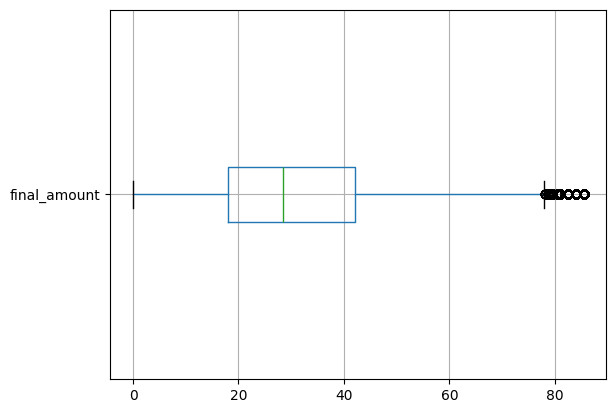

In [59]:
skew_dfTrans = df_Trans['final_amount'].skew()
print(f"Skewness sebelum transformasi: {skew_dfTrans}")
df_Trans[["final_amount"]].boxplot(vert=False);
plt.show()

metode IQR:
skewness setelah IQR: 0.45


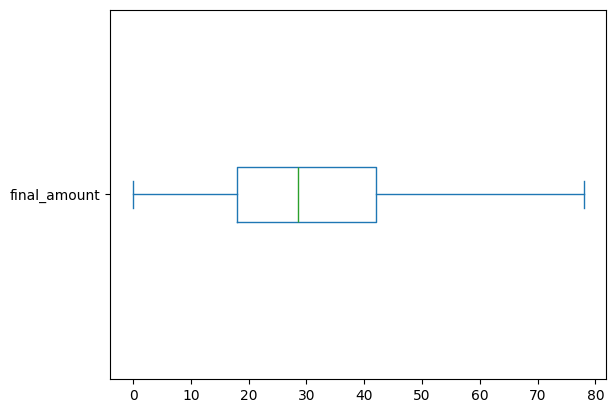

metode Capping:
skewness setelah Capping: 0.44


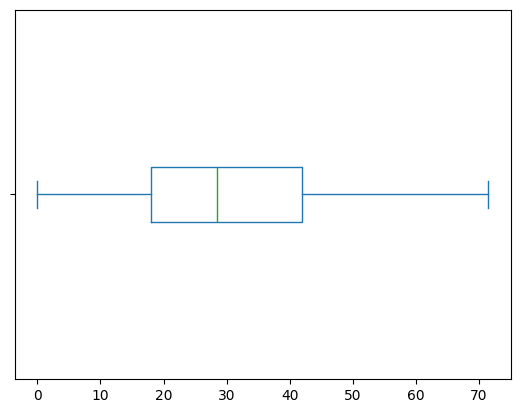

metode Z-Score:
skewness setelah Z-Score: 0.45


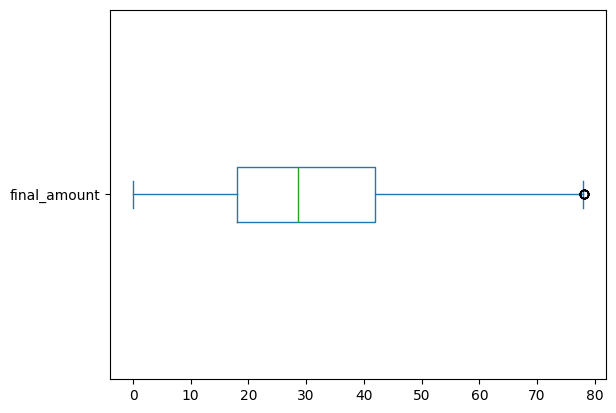

Jumlah data sebelum menangani outlier: 14623691
 
      Jumlah data setelah IQR: 14593058
Persentase: 0.21%
 
      Jumlah data setelah Capping: 14623691
Persentase: 0.00%
 
      Jumlah data setelah Z-Score: 14593072
Persentase: 0.21%


In [60]:
c= CleaningData(df_Trans)
print('metode IQR:')
_,_,iqr_Data = c.iqr('final_amount')
skew_iqr = iqr_Data.skew()
print(f'skewness setelah IQR: {skew_iqr:.2f}')
c.BoxPlot('final_amount', Target=iqr_Data)

print('metode Capping:')
_,_,capped_data = c.capping('final_amount')
skew_capped = capped_data.skew()
print(f'skewness setelah Capping: {skew_capped:.2f}')
c.BoxPlot('final_amount', Target=capped_data)

print('metode Z-Score:')
_,_,z_data = c.z_score_method('final_amount')
skew_z = z_data.skew()
print(f'skewness setelah Z-Score: {skew_z:.2f}')
c.BoxPlot('final_amount', Target=z_data)

print(f'''Jumlah data sebelum menangani outlier: {len(df_Trans)}\n 
      Jumlah data setelah IQR: {len(iqr_Data)}\nPersentase: {(1 - len(iqr_Data) / len(df_Trans)) * 100:.2f}%\n 
      Jumlah data setelah Capping: {len(capped_data)}\nPersentase: {(1 - len(capped_data) / len(df_Trans)) * 100:.2f}%\n 
      Jumlah data setelah Z-Score: {len(z_data)}\nPersentase: {(1 - len(z_data) / len(df_Trans)) * 100:.2f}%''')



In [61]:
gc.collect()

5989

Persebaran transformasi Z-Score:


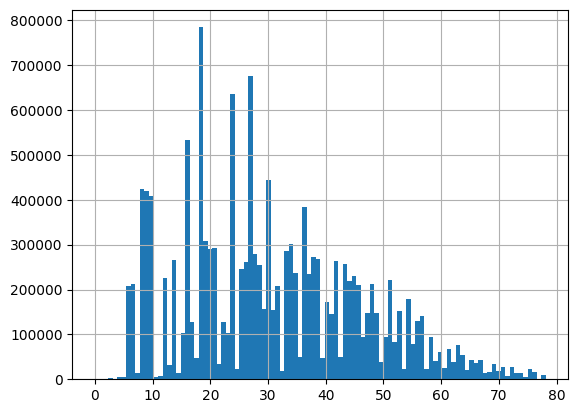

Persebaran transformasi IQR:


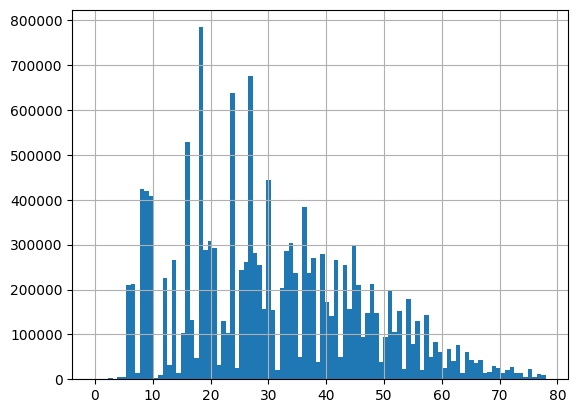

Persebaran transformasi Capping:


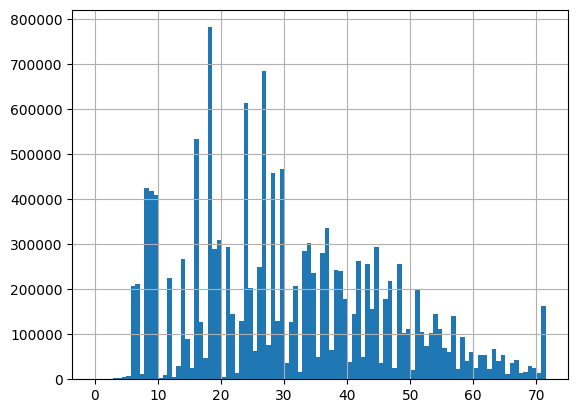

In [62]:
print('Persebaran transformasi Z-Score:')
c.HistPlot('final_amount', Target=z_data)
print('Persebaran transformasi IQR:')
c.HistPlot('final_amount', Target=iqr_Data)
print('Persebaran transformasi Capping:')
c.HistPlot('final_amount', Target=capped_data)

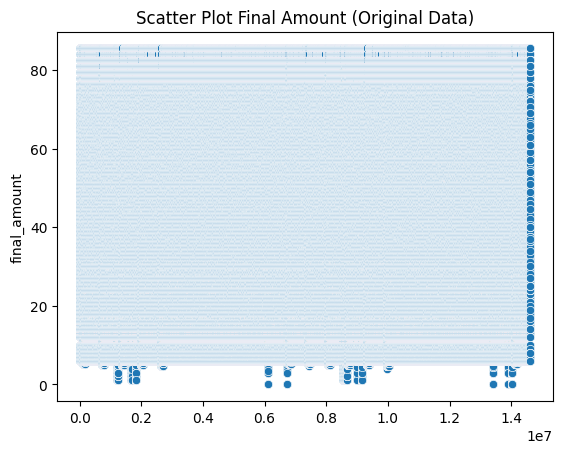

In [63]:
sns.scatterplot(
    data = df_Trans['final_amount']
).set(title='Scatter Plot Final Amount (Original Data)')
plt.show()


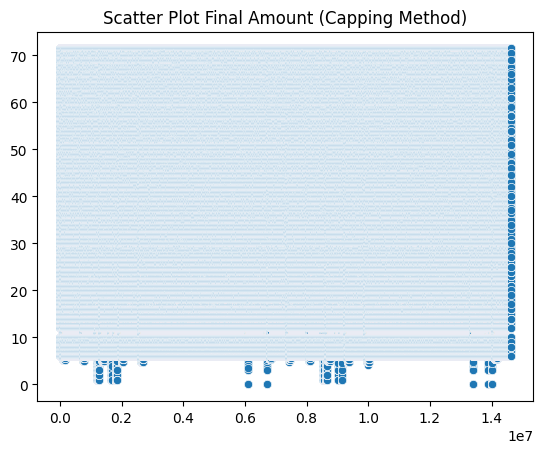

In [64]:
sns.scatterplot(
    data = capped_data
).set(title='Scatter Plot Final Amount (Capping Method)')
plt.show()


In [65]:
gc.collect()

29824

## df Trans Item

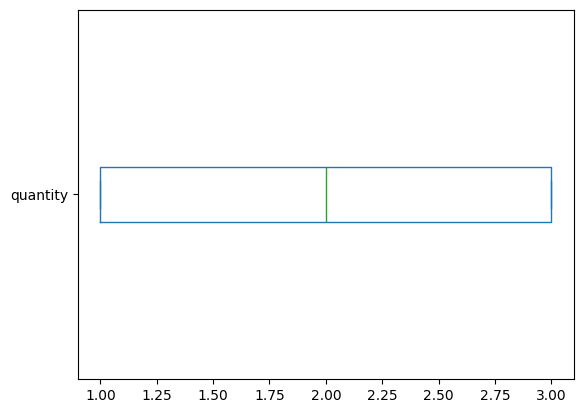

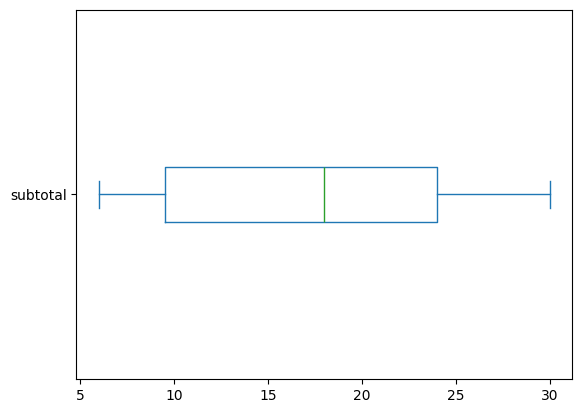

In [66]:
CleaningData(df_TransItem).BoxPlot('quantity')
CleaningData(df_TransItem).BoxPlot('subtotal')

# Pipeline

In [67]:
TransCapping = df_Trans.copy()

TransCapping['final_amount']= capped_data

# Cleaned Data

In [68]:
TransCapping.to_parquet('transactions_capping.parquet', index=False, compression='snappy')
df_TransItem.to_parquet('transaction_items_cleaned.parquet', index=False, compression='snappy')
df_Users.to_parquet('users_cleaned.parquet', index=False, compression='snappy')
df_menu.to_parquet('menu_cleaned.parquet', index=False, compression='snappy')
df_stores.to_parquet('stores_cleaned.parquet', index=False, compression='snappy')

In [69]:
gc.collect()

9101